In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

In [3]:
titantic_df = pd.read_csv("/content/drive/MyDrive/dsml12/titanic-data.csv")

In [4]:
titantic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
# Renaming Columns

# Pclass = PStatus
# Sex = Gender

In [6]:
titantic_df.rename(
    columns={'Pclass':'PStatus','Sex':'Gender'}, inplace=True)

In [7]:
titantic_df.head()

,PassengerId,Survived,PStatus,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
# Handling Incorrect Data

import numpy as np

data = pd.DataFrame({
    "id":[1,3,5,7,9],
    "name":["John","Jane","Jennifer","Johan","Jeff"],
    "age":[25,-32,19,42,"55"],
    "gender" : ["M","M","Z","F","F"],
    "income":[400, 700, 300, np.nan, 600]
})

In [9]:
data

,id,name,age,gender,income
0,1,John,25,M,400.0
1,3,Jane,-32,M,700.0
2,5,Jennifer,19,Z,300.0
3,7,Johan,42,F,NaN
4,9,Jeff,55,F,600.0


In [10]:
# Handling incorrect data

In [11]:
data.dtypes

,0
id,int64
name,object
age,object
gender,object
income,float64


In [12]:
data.age = data.age.astype(int)

In [13]:
data

,id,name,age,gender,income
0,1,John,25,M,400.0
1,3,Jane,-32,M,700.0
2,5,Jennifer,19,Z,300.0
3,7,Johan,42,F,NaN
4,9,Jeff,55,F,600.0


In [14]:
data.age = abs(data.age)
data

,id,name,age,gender,income
0,1,John,25,M,400.0
1,3,Jane,32,M,700.0
2,5,Jennifer,19,Z,300.0
3,7,Johan,42,F,NaN
4,9,Jeff,55,F,600.0


In [15]:
data.dtypes

,0
id,int64
name,object
age,int64
gender,object
income,float64


In [16]:
# Class work

# Set the boundary remove less than 18, above 45

In [17]:
# Boundary

filter_age = data[(data.age >= 18) & (data.age <= 45)]
filter_age

,id,name,age,gender,income
0,1,John,25,M,400.0
1,3,Jane,32,M,700.0
2,5,Jennifer,19,Z,300.0
3,7,Johan,42,F,NaN


In [18]:
data[data.gender.isin(["M","F"])]

,id,name,age,gender,income
0,1,John,25,M,400.0
1,3,Jane,32,M,700.0
3,7,Johan,42,F,NaN
4,9,Jeff,55,F,600.0


In [19]:
# .isin() to filter to the DataFrame

In [20]:
data[data.name.isin(["John"])]

,id,name,age,gender,income
0,1,John,25,M,400.0


In [21]:
# Saving a dataframe

titantic_df.to_csv("clean_data.csv", index=False)

In [22]:
data.to_json("clean_data.json", index=False, orient="records")

The Chi-Square (χ²) test is a statistical test used in data science to determine whether there is a significant relationship between categorical variables or whether the observed data differs from what we would expect by chance

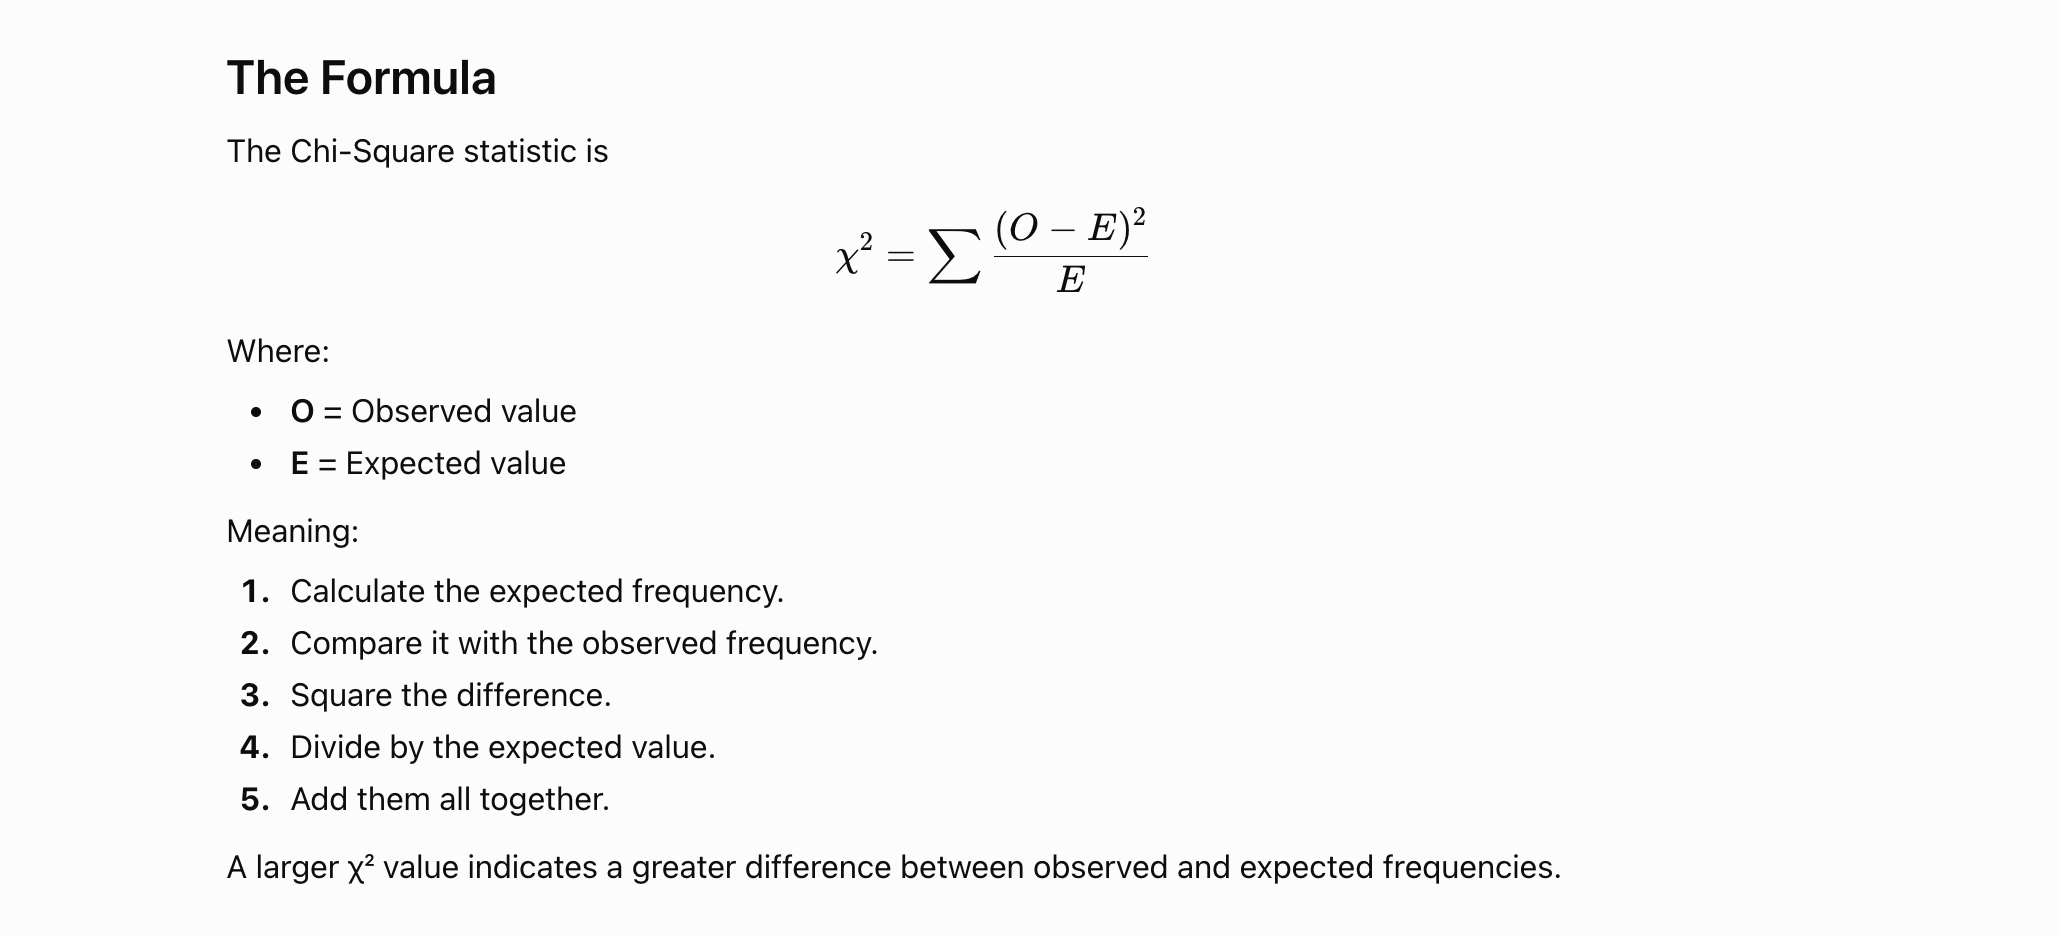

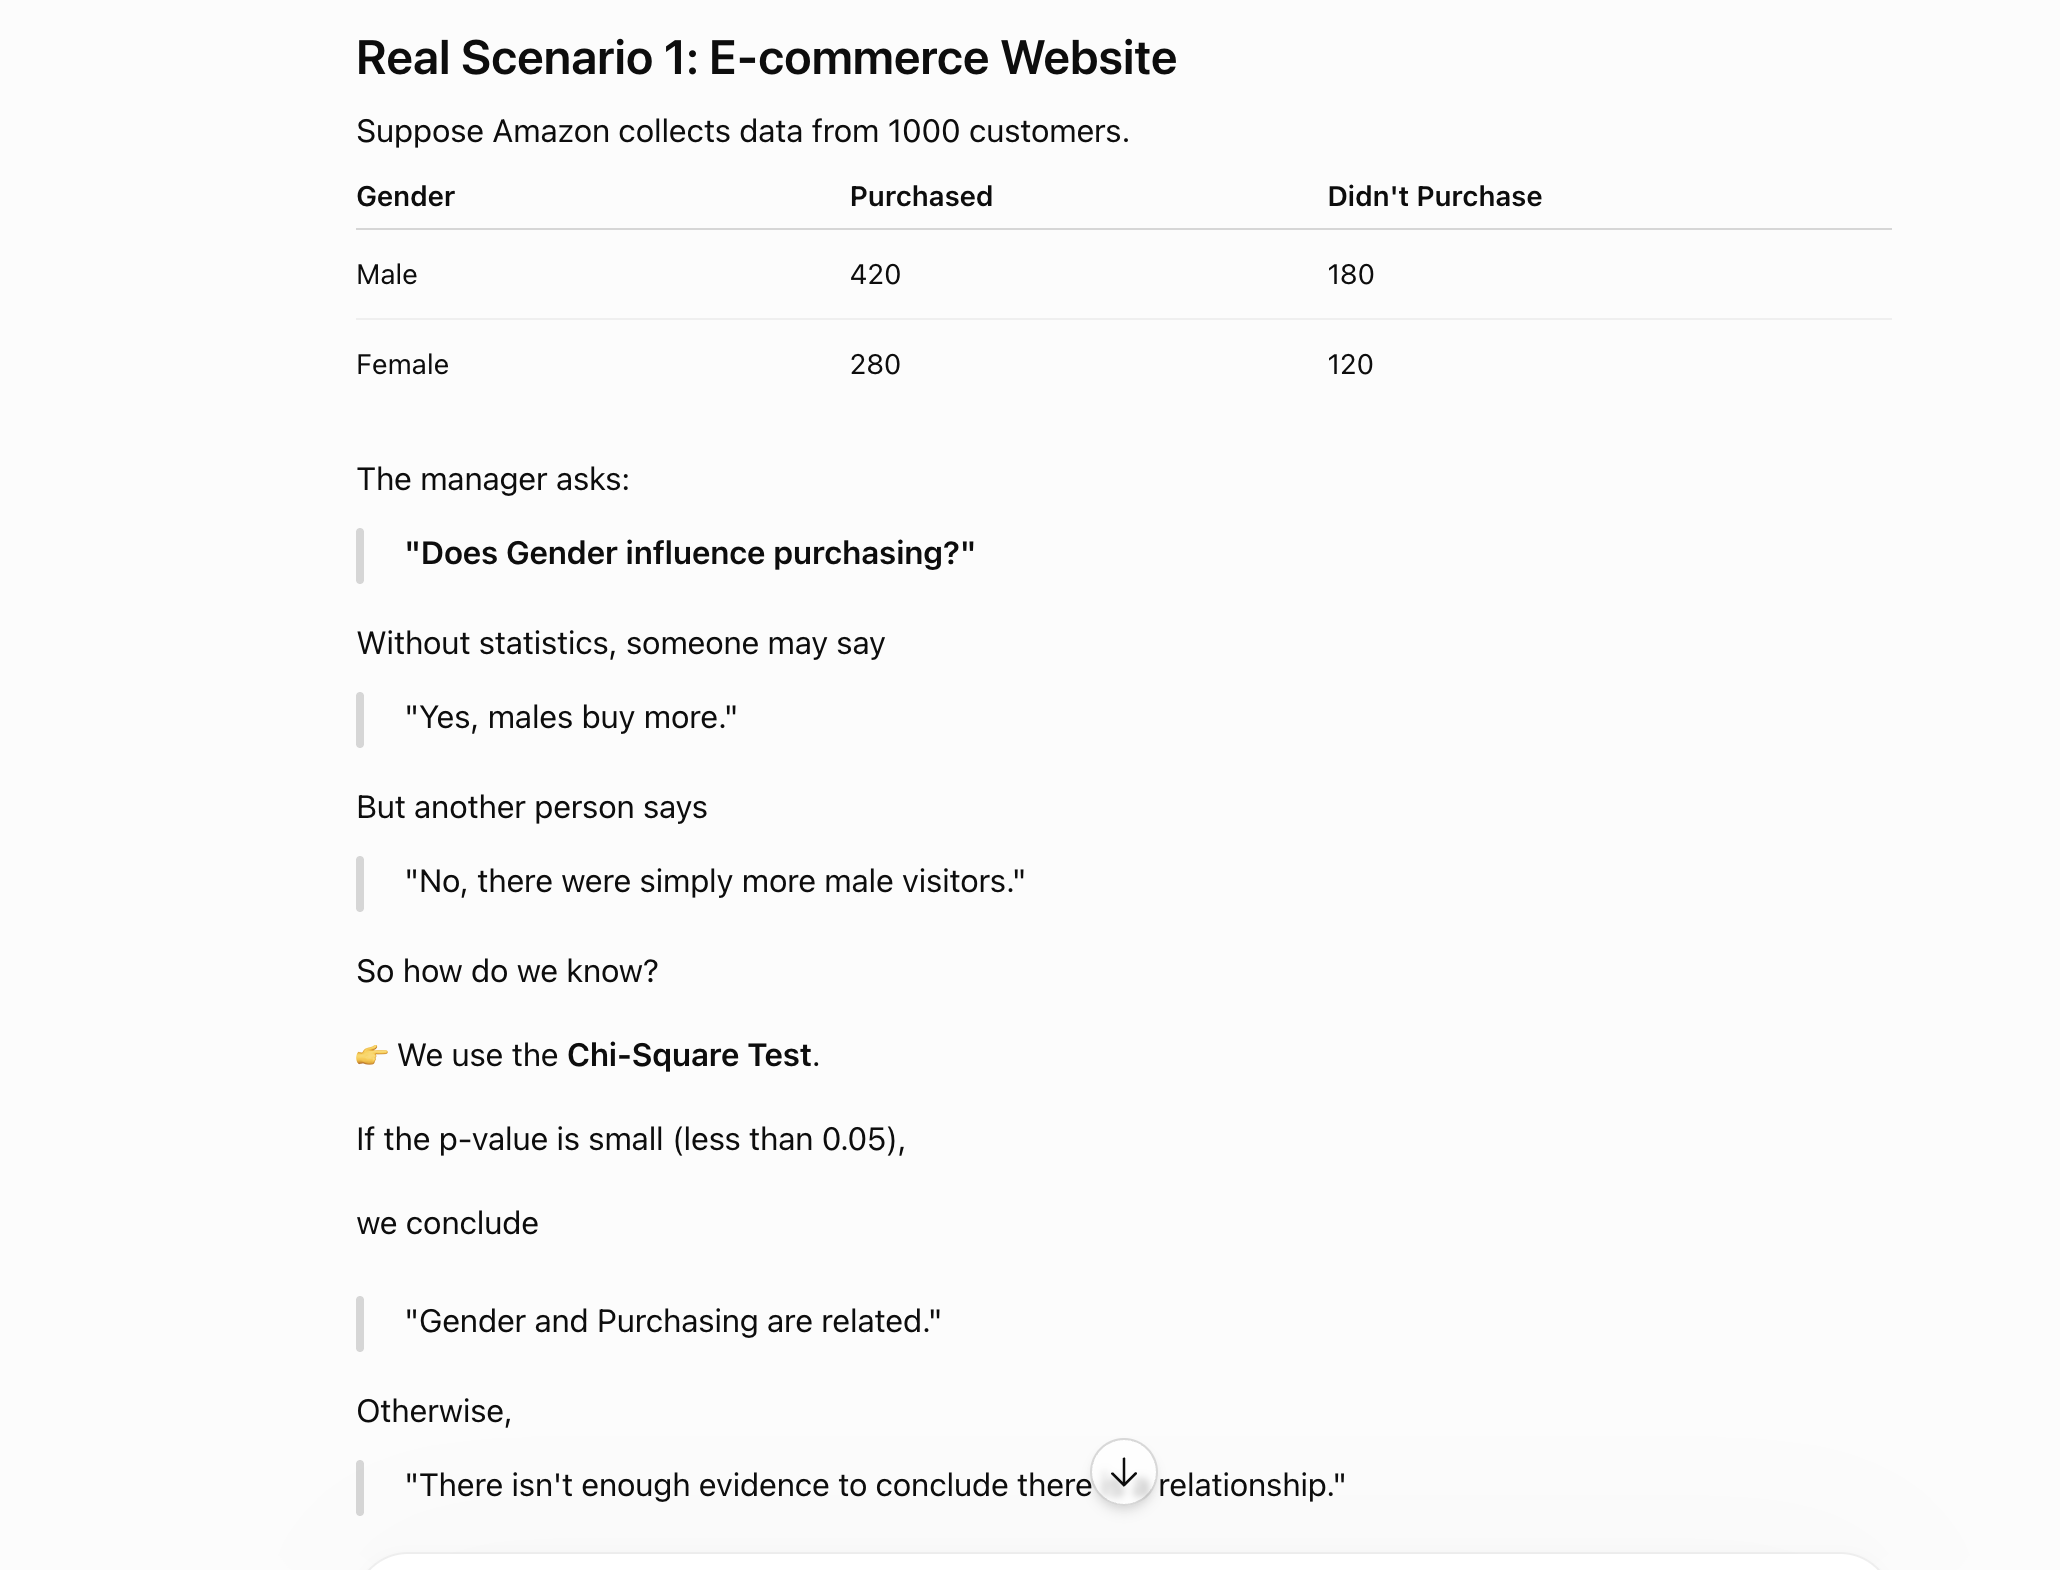

In [23]:
import pandas as pd

data = {
    "Gender": ["Male", "Male", "Male", "Female", "Female", "Female",
               "Male", "Female", "Male", "Female"],
    "Purchased": ["Yes", "No", "Yes", "No", "Yes", "No",
                  "Yes", "No", "Yes", "Yes"]
}

df = pd.DataFrame(data)

print(df)

   Gender Purchased
0    Male       Yes
1    Male        No
2    Male       Yes
3  Female        No
4  Female       Yes
5  Female        No
6    Male       Yes
7  Female        No
8    Male       Yes
9  Female       Yes


In [24]:
contingency_table = pd.crosstab(df["Gender"], df["Purchased"])

contingency_table

Purchased,No,Yes
Gender,,
Female,3,2
Male,1,4


In [25]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-squared statistic:", chi2)
print("Degree of Freedom", dof)
print("P-value:", p)
print(expected)

Chi-squared statistic: 0.41666666666666663
Degree of Freedom 1
P-value: 0.5186050164287255
[[2. 3.]
 [2. 3.]]


In [26]:
alpha = 0.05

if p < alpha:
    print("Reject the null hypothesis")
else:
    print("Fail to reject the null hypothesis")

Fail to reject the null hypothesis


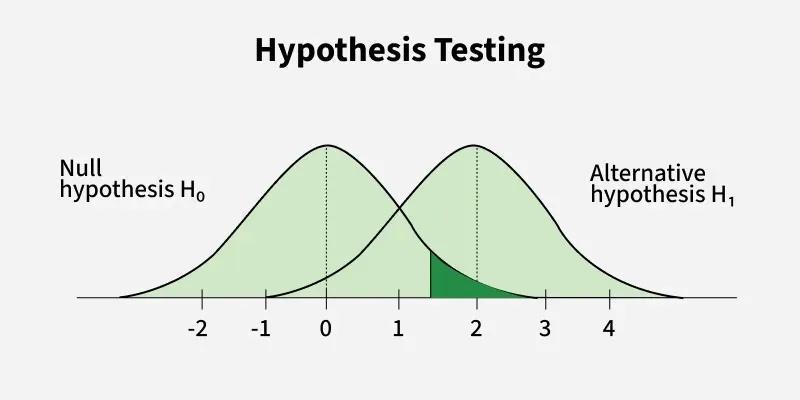

In [27]:
# Degree of freedom = (rows -1) * (columns -1)

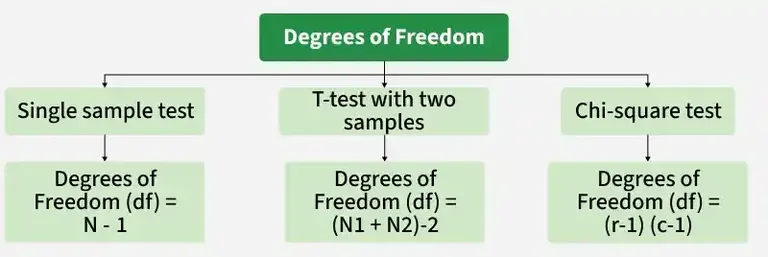

Listwise deletion

pairwise deletion

dropping variables

single imputation = hot/cold imputation, mean median , mode, last observed value, linear interpolation,

Multiple Imputaion = MICE algorithm